# Exercise 2 - classification

## 0. Alternativ faster way to read the dataset

In [77]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
 
df = iris.frame.copy() #hämtar hem datan som en dataframe
# df = load_iris(as_frame = True).frame => Gör allt i ett steg
 
df.head()
 
 

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 0. Iris flower 

In the whole exercise, we will work with the famous Iris flower dataset, which was collected in 1936 by Ronald Fisher, a statistician and biologist. Use the datasets module from scikit-learn to load the iris dataset.

  a) Check keys on the loaded data and check what the different values for each key are.

In [2]:
from sklearn.datasets import load_iris

data = load_iris()
type(data)

sklearn.utils._bunch.Bunch

In [3]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [6]:
# to see metadata and read about the dataset
# print(data["DESCR"])

In [9]:
# 150 samples, 4 features
data["data"].shape

(150, 4)

In [13]:
data["feature_names"]

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [11]:
data["target"]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [12]:
data["target_names"]

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

  b) Now insert the data into a DataFrame.

In [20]:
import pandas as pd 

df = pd.DataFrame(data["data"], columns=data["feature_names"])

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [24]:
df_target = pd.DataFrame(data["target"], columns=["class"])
df_target.head()

,class
0,0
1,0
2,0
3,0
4,0


In [31]:
df_iris = pd.concat([df, df_target], axis="columns")
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


  c) Do some EDA to get an understanding of the dataset.

In [32]:
df_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   class              150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [36]:
# when testing the algorithm with some fake data -> get a sense of the ranges that we can use
# when validating input data
df_iris.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
class,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


for class 0 in general 
- shortest sepal length
- longest sepal width
- petal length and petal width shortest

...

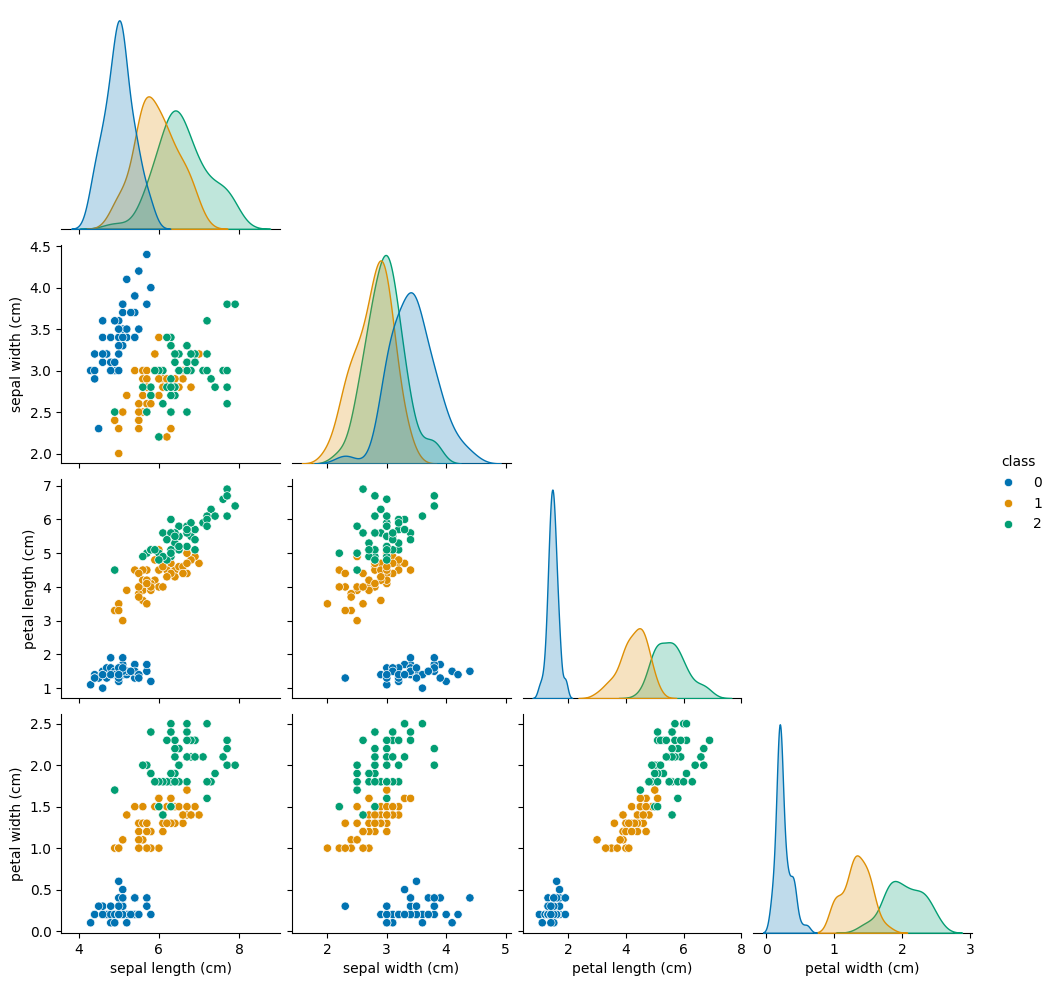

In [41]:
import seaborn as sns

sns.pairplot(df_iris, corner=True, hue="class", palette="colorblind")

d) Make a correlation heatmap to see how each feature is correlated to each other. What do the numbers mean?

In [42]:
df_iris.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
class,0.782561,-0.426658,0.949035,0.956547,1.000000


<Axes: >

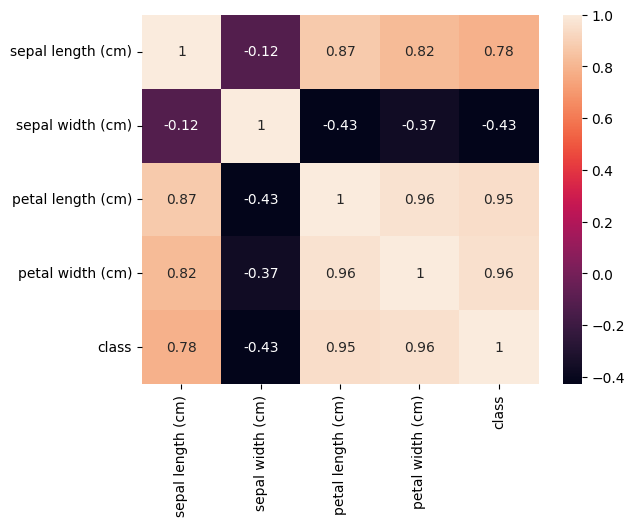

In [44]:
sns.heatmap(df_iris.corr(), annot=True)

  e) Make a boxplot. The points outside of the boxplot are statistically calculated outliers using Tukey's rule for boxplot.

<Axes: >

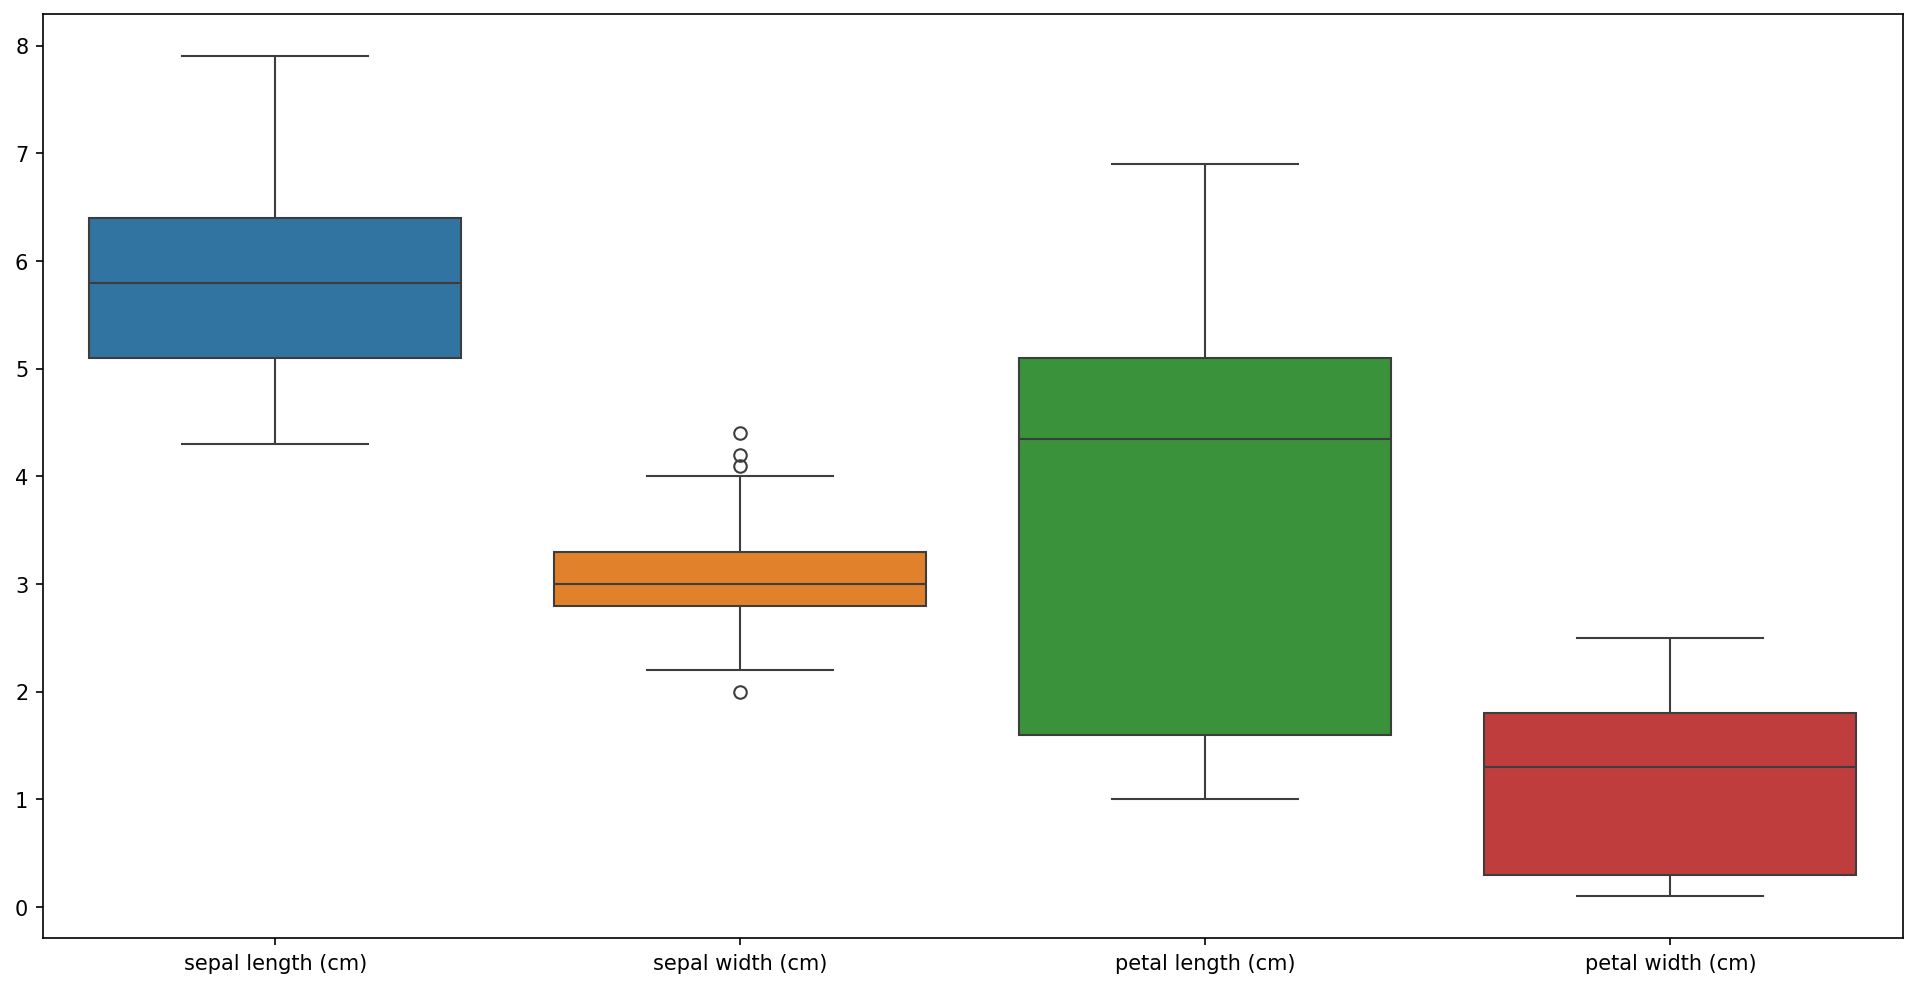

In [49]:
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(1, figsize = (16,8), dpi = 150)
sns.boxplot(df)

f) Now remove the outliers in data. (\*\*)

- Lower bound outlier: $Q_1 - 1.5\cdot IQR$
- Upper bound outlier: $Q_3 + 1.5\cdot IQR$

where $Q_1$ is the 1st quartile or 25 percentile, $Q_3$ is the 3rd quartile or 75 percentile and $IQR = Q_3-Q_1$ is the interquartile range.

In [51]:
q1 = df_iris["sepal width (cm)"].quantile(.25)
q1

np.float64(2.8)

In [52]:
q3 = df_iris["sepal width (cm)"].quantile(.75)
q3

np.float64(3.3)

In [53]:
iqr =  q3-q1
iqr

np.float64(0.5)

In [54]:
lower_bound = q1-1.5*iqr
higher_bound = q3+1.5*iqr

lower_bound, higher_bound

(np.float64(2.05), np.float64(4.05))

In [58]:

(df_iris["sepal width (cm)"] > lower_bound).sum()

np.int64(149)

In [59]:

(df_iris["sepal width (cm)"] < higher_bound).sum()

np.int64(147)

In [62]:
df_no_outliers = df_iris[
    (df_iris["sepal width (cm)"] > lower_bound)
    & (df_iris["sepal width (cm)"] < higher_bound)
]

df_no_outliers.shape

(146, 5)

  g) Do train|test split on the dataset and then scale it with feature standardization.

In [64]:
from sklearn.model_selection import train_test_split

X, y = df_no_outliers.drop("class", axis = 1), df_no_outliers["class"]

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [65]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: class, dtype: int64

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
X_train.shape, X_test.shape

((97, 4), (49, 4))

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)


scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

scaled_X_train.mean(), scaled_X_train.std(), scaled_X_test.mean(), scaled_X_test.std()

(np.float64(2.998746726307124e-16),
 np.float64(0.9999999999999998),
 np.float64(-0.026200181679167715),
 np.float64(0.9999349444958894))

 h) Classify using logistic regression

   i) Classify the first 10 values of your X_test
 and compare it manually with your labels.

In [70]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(scaled_X_train, y_train)

model.predict(scaled_X_test)[:10]

array([0, 2, 0, 0, 0, 2, 0, 1, 2, 0])

In [72]:
y_test.iloc[:10].values

array([0, 2, 0, 0, 0, 2, 0, 1, 1, 0])

  j) Evaluate your model using classification report and confusion matrix.

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.91      0.95        11
           2       0.95      1.00      0.97        19

    accuracy                           0.98        49
   macro avg       0.98      0.97      0.98        49
weighted avg       0.98      0.98      0.98        49



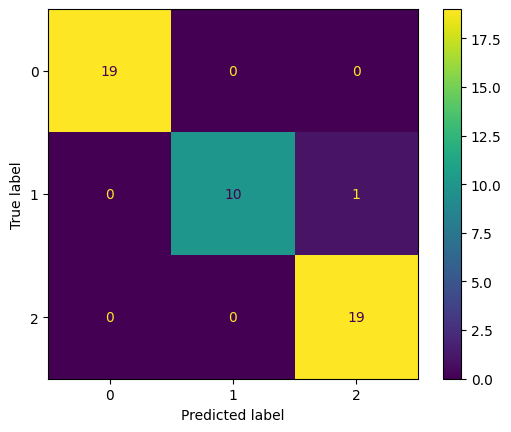

In [76]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(scaled_X_test)

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()